<a href="https://colab.research.google.com/github/ArushRastogi47/10x.ai/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ArushRastogi47/10x.ai/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [2]:
import os, subprocess, json
import numpy as np
import pandas as pd
import duckdb
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
REPO_DIR = "10x.ai"
if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/ArushRastogi47/10x.ai", REPO_DIR], check=True)
os.chdir(REPO_DIR)
os.makedirs("work/outputs", exist_ok=True)

con = duckdb.connect()
con.execute(f"CREATE SECRET IF NOT EXISTS hf_sec (TYPE huggingface, TOKEN '{os.environ['HF_TOKEN']}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
print("setup ok, cwd =", os.getcwd())

setup ok, cwd = /content/10x.ai


In [3]:
def windows(decision_date: str):
    d = pd.Timestamp(decision_date)
    w1e = d
    w1s = d - pd.DateOffset(days=29)
    w2e = w1s - pd.DateOffset(days=1)
    w2s = w2e - pd.DateOffset(days=29)
    w3e = w2s - pd.DateOffset(days=1)
    w3s = w3e - pd.DateOffset(days=59)
    return [x.date().isoformat() for x in (w1s, w1e, w2s, w2e, w3s, w3e,
                                           d + pd.DateOffset(days=1), d + pd.DateOffset(days=30))]

def build_frame(decision_date: str, feat_globs, out_globs) -> pd.DataFrame:
    w1s, w1e, w2s, w2e, w3s, w3e, o_start, o_end = windows(decision_date)
    sql = f"""
    WITH f AS (
      SELECT client_hash_id, content_hash_id, report_date,
             gsc_impressions, gsc_clicks, gsc_avg_position
      FROM read_parquet({feat_globs})
      WHERE gsc_data_available IS TRUE
        AND report_date BETWEEN DATE '{w3s}' AND DATE '{w1e}'
    ),
    feat AS (
      SELECT client_hash_id, content_hash_id,
        SUM(gsc_impressions) FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w1e}') AS impr_trailing30,
        SUM(gsc_impressions) FILTER (report_date BETWEEN DATE '{w2s}' AND DATE '{w2e}') AS impr_prior30,
        SUM(gsc_impressions) FILTER (report_date BETWEEN DATE '{w3s}' AND DATE '{w3e}') AS impr_early60,
        SUM(gsc_clicks)      FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w1e}') AS clicks_w1,
        SUM(gsc_clicks)      FILTER (report_date BETWEEN DATE '{w2s}' AND DATE '{w2e}') AS clicks_w2,
        SUM(gsc_impressions) FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w2e}') AS impr_60d,
        AVG(gsc_avg_position) FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w1e}') AS pos_w1,
        AVG(gsc_avg_position) FILTER (report_date BETWEEN DATE '{w2s}' AND DATE '{w2e}') AS pos_w2,
        AVG(gsc_avg_position) FILTER (report_date BETWEEN DATE '{w1s}' AND DATE '{w2e}') AS position_mean_60d,
        STDDEV(gsc_impressions) FILTER (report_date BETWEEN DATE '{w3s}' AND DATE '{w1e}') AS std_impr_90d,
        AVG(gsc_impressions)    FILTER (report_date BETWEEN DATE '{w3s}' AND DATE '{w1e}') AS avg_daily_impr_90d,
        COUNT(DISTINCT report_date) AS days_seen_90d
      FROM f GROUP BY 1, 2
    ),
    outcome AS (
      SELECT content_hash_id, SUM(gsc_impressions) AS impr_outcome
      FROM read_parquet({out_globs})
      WHERE gsc_data_available IS TRUE
        AND report_date BETWEEN DATE '{o_start}' AND DATE '{o_end}'
      GROUP BY 1
    )
    SELECT feat.*, COALESCE(o.impr_outcome, 0) AS impr_outcome,
           (COALESCE(o.impr_outcome, 0) < feat.impr_trailing30)::INT AS label_declined
    FROM feat LEFT JOIN outcome o USING (content_hash_id)
    """
    df = con.sql(sql).df()
    df["momentum_30d"]  = df["impr_trailing30"] / df["impr_prior30"].replace(0, np.nan)
    df["momentum_90d"]  = df["impr_trailing30"] / (df["impr_prior30"] + df["impr_early60"]).replace(0, np.nan)
    df["ctr_w1"]        = df["clicks_w1"] / df["impr_trailing30"].replace(0, np.nan)
    df["ctr_w2"]        = df["clicks_w2"] / df["impr_prior30"].replace(0, np.nan)
    df["ctr_60d"]       = (df["clicks_w1"] + df["clicks_w2"]) / df["impr_60d"].replace(0, np.nan)
    df["ctr_momentum"]  = df["ctr_w1"] - df["ctr_w2"]
    df["position_momentum"] = df["pos_w1"] - df["pos_w2"]
    df["volatility_90d"] = df["std_impr_90d"] / df["avg_daily_impr_90d"].replace(0, np.nan)
    df["presence_90d"]   = df["days_seen_90d"] / 90.0
    return df

FEATURES = ["impr_trailing30", "momentum_30d", "momentum_90d", "position_mean_60d",
            "position_momentum", "ctr_60d", "ctr_momentum", "volatility_90d",
            "days_seen_90d", "presence_90d"]
OUTCOME_COLS = ["impr_outcome", "label_declined"]
print("builder ready:", len(FEATURES), "features; label = outcome window < trailing 30d (proxy, ML-04 verified rule)")

builder ready: 10 features; label = outcome window < trailing 30d (proxy, ML-04 verified rule)


In [4]:
# Dev frame: decide 2026-03-31 -> outcome April. Test frame: decide 2026-05-31 -> outcome June (_sample, sealed).
if os.path.exists("work/outputs/capstone_dev_frame.csv"):
    dev = pd.read_csv("work/outputs/capstone_dev_frame.csv"); print("dev from cache:", len(dev))
else:
    dev = build_frame("2026-03-31",
        feat_globs=[f"{rel}/fact_content_daily_performance/month=2025-12/*.parquet",
                    f"{rel}/fact_content_daily_performance/month=2026-0[1-4]/*.parquet"],
        out_globs=[f"{rel}/fact_content_daily_performance/month=2026-04/*.parquet"])
    dev.to_csv("work/outputs/capstone_dev_frame.csv", index=False); print("dev built:", len(dev))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

dev built: 209493


In [6]:
if os.path.exists("work/outputs/capstone_test_frame.csv"):
    test = pd.read_csv("work/outputs/capstone_test_frame.csv"); print("test from cache:", len(test))
else:
    test = build_frame("2026-05-31",
        feat_globs=[f"{rel}/fact_content_daily_performance/month=2026-0[3-5]/*.parquet"],
        out_globs=[f"{rel}/fact_content_daily_performance/month=2026-06/*.parquet"])
    test.to_csv("work/outputs/capstone_test_frame.csv", index=False); print("test built:", len(test))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

test built: 258233


In [7]:
for name, df in [("dev", dev), ("test", test)]:
    d = df.dropna(subset=FEATURES + ["label_declined"])
    print(f"{name}: {len(df)} raw pages, {len(d)} modelable, "
          f"decline rate {d['label_declined'].mean():.3f}, dropped {len(df)-len(d)}")

dev: 209493 raw pages, 0 modelable, decline rate <NA>, dropped 209493
test: 258233 raw pages, 0 modelable, decline rate <NA>, dropped 258233


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [8]:
con.sql(f"""
SELECT
  COUNT(*) AS rows,
  MIN(report_date) AS min_date, MAX(report_date) AS max_date,
  ROUND(100.0 * COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) / COUNT(*), 1) AS pct_gsc_available
FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet')
""").df()

,rows,min_date,max_date,pct_gsc_available
0,9841378,2026-03-01,2026-03-31,36.7


## 3. Methodology

> **Assumptions:** past traffic patterns are *directional* evidence about the next 30 days; pages absent from the outcome window count as 0 impressions (declining). Both are assumptions, stated.
> **Label (proxy):** `declined` = outcome-window impressions < trailing-30-day impressions. Defined rule from ML-04, re-verified in the ML-04 leakage experiment — never a feature.
> **Features (10):** trailing-30d impressions; momentum 30d and 90d; mean position 60d; position momentum; CTR 60d; CTR momentum; impression volatility 90d; days seen 90d; presence share 90d. Every one is computed strictly from windows ending at the decision date.
> **Baseline:** the frozen ML-07 hand rule (visibility floor × month-over-month fall), re-scored on this frame's windows for a same-split comparison; ML-07's metrics JSON is the external receipt.
> **Validation design:** client-holdout split on the dev frame (a client's pages never appear on both sides). Metric: Precision@20/50 against the base rate.
> **Leakage checks:** features hard-bounded to `report_date <= decision date` in SQL; rule/model inputs disjoint from outcome columns (asserted in section 5); the ML-04 deliberate-trap lesson carried forward.

In [11]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(labels)[order[:k]].mean())

d = dev.dropna(subset=["label_declined", "client_hash_id"]).reset_index(drop=True).copy()

# Check if the DataFrame 'd' is empty after dropping NaNs
if d.empty:
    print("Warning: DataFrame 'd' is empty after dropping rows with NaN in label_declined or client_hash_id. Cannot proceed with model training.")
else:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    tr, te = next(gss.split(d[FEATURES], d["label_declined"], groups=d["client_hash_id"]))
    y_te = d.loc[te, "label_declined"].values
    print(f"clients {d['client_hash_id'].nunique()} | train {len(tr)} | holdout {len(te)}")

    rule_score = (d.loc[te, "impr_trailing30"]
                  * (1 - d.loc[te, "momentum_30d"].fillna(1)).clip(lower=0))
    models = {
        "hand_rule_frozen": None,
        "logistic_regression": make_pipeline(SimpleImputer(strategy="median"),
                                             LogisticRegression(max_iter=2000)),
        "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=42),
    }
    fitted = {}
    scores_holdout = {"hand_rule_frozen": rule_score}
    for name, mdl in models.items():
        if mdl is None: continue
        mdl.fit(d.loc[tr, FEATURES], d.loc[tr, "label_declined"])
        fitted[name] = mdl
        scores_holdout[name] = mdl.predict_proba(d.loc[te, FEATURES])[:, 1]
    print("models fitted")

clients 47 | train 130513 | holdout 45755


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['position_mean_60d' 'ctr_60d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['position_mean_60d' 'ctr_60d']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


models fitted


## 4. Results (vs baseline)

> The honest table: every model and the frozen rule on the **same holdout rows**, Precision@20/50 next to the base rate. Then the frozen winner gets exactly one run on the sealed June frame. *Replace the sentence below with your measured numbers after running.*
>
> _Template: On the dev client-holdout, [model] scored Precision@50 = [x] vs the frozen hand rule's [y] (base rate [z]). On the sealed June frame, one frozen run measured Precision@50 = [w]. Directionally, the model [does / does not] beat the readable baseline at the top of the queue._

In [12]:
results_df = pd.DataFrame([
    {"model": "base_rate", "p@20": round(float(y_te.mean()), 3), "p@50": round(float(y_te.mean()), 3)}
] + [{"model": name,
      "p@20": round(precision_at_k(s, y_te, 20), 3),
      "p@50": round(precision_at_k(s, y_te, 50), 3)}
     for name, s in scores_holdout.items()])
results_df

,model,p@20,p@50
0,base_rate,0.546,0.546
1,hand_rule_frozen,0.700,0.560
2,logistic_regression,0.750,0.860
3,hist_gradient_boosting,0.950,0.900


In [13]:
# Freeze the winner (highest p@50; ties -> simpler model), refit on ALL dev rows, ONE run on June.
cand = results_df[results_df["model"] != "base_rate"]
top = cand[cand["p@50"] == cand["p@50"].max()]
winner_name = "logistic_regression" if "logistic_regression" in top["model"].values else top.iloc[0]["model"]
print("frozen winner:", winner_name)

final_model = fitted[winner_name]
final_model.fit(d[FEATURES], d["label_declined"])   # single final refit on full dev frame

dt = test.dropna(subset=["label_declined"]).copy()
s_test = final_model.predict_proba(dt[FEATURES])[:, 1]
final_metrics = {
    "winner": winner_name,
    "n_test_pages": int(len(dt)),
    "base_rate": round(float(dt["label_declined"].mean()), 3),
    "precision_at_20": precision_at_k(s_test, dt["label_declined"], 20),
    "precision_at_50": precision_at_k(s_test, dt["label_declined"], 50),
}
print(json.dumps(final_metrics, indent=2))
with open("work/outputs/capstone_final_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

frozen winner: hist_gradient_boosting
{
  "winner": "hist_gradient_boosting",
  "n_test_pages": 237429,
  "base_rate": 0.781,
  "precision_at_20": 0.75,
  "precision_at_50": 0.8
}


## 5. Limitations

> - **Unbalanced panel (observed):** clients entered at different times — identical windows cover different real history per client. Features are directional decision-support, not cross-client absolutes.
> - **One sealed test window (measured):** the June number is one honest out-of-time measurement, not a performance guarantee.
> - **Proxy label (defined, not observed truth):** "declining" is a traffic rule, not a business outcome; no causal refresh claim is made.
> - **GSC-only slice:** GA4 engagement is unavailable for many clients; on-page behavior is out of contract.
> - **Depth-2/queue caveat carried from ML-02:** precision at the very top of a ranked list is what the team acts on; small-sample K values (20, 50) are noisy — directional, not definitive.

*Leakage audit: model inputs must be disjoint from outcome columns, and the holdout score must not change when outcome columns are dropped.*

In [14]:
assert set(FEATURES).isdisjoint(OUTCOME_COLS)
label_free = dev.drop(columns=OUTCOME_COLS)
s_lf = final_model.predict_proba(label_free.loc[te, FEATURES])[:, 1]
print("holdout P@50 with outcome columns dropped:",
      round(precision_at_k(s_lf, y_te, 50), 3),
      "| must equal section-4 value:",
      round(precision_at_k(scores_holdout[winner_name], y_te, 50), 3))

holdout P@50 with outcome columns dropped: 0.58 | must equal section-4 value: 0.9


## 6. Ranked recommendations

> The action playbook: the final model scores the current queue (decision date 2026-05-31). Reason codes and actions follow the ML-07 scheme so a human can read every row. The CSV regenerates on every run and stays out of git.

In [15]:
FLOOR = 100  # same visibility floor as ML-07
rec = test.copy()
rec["score"] = final_model.predict_proba(rec[FEATURES])[:, 1]
rec["reason_code"] = np.select(
    [(rec["impr_trailing30"] >= FLOOR) & (rec["momentum_30d"] < 1),
     (rec["impr_trailing30"] <  FLOOR) & (rec["momentum_30d"] < 1)],
    ["FALLING_HIGH_VOLUME", "FALLING_LOW_VOLUME"], default="NOT_DECLINING_SIGNAL")
rec["action"] = np.select(
    [rec["reason_code"].eq("FALLING_HIGH_VOLUME"), rec["reason_code"].eq("FALLING_LOW_VOLUME")],
    ["REFRESH_NOW", "REVIEW"], default="MONITOR")
rec = rec.sort_values("score", ascending=False).reset_index(drop=True)
rec.insert(0, "rank", rec.index + 1)
cols = ["rank", "client_hash_id", "content_hash_id", "score", "reason_code", "action",
        "impr_trailing30", "momentum_30d", "position_mean_60d", "ctr_60d", "days_seen_90d"]
rec.head(50)[cols].to_csv("work/outputs/capstone_top50_recommendations.csv", index=False)
rec.head(15)[cols]

,rank,client_hash_id,content_hash_id,score,reason_code,action,impr_trailing30,momentum_30d,position_mean_60d,ctr_60d,days_seen_90d
0,1,client_62f4a7e64f5e0096,content_dda03753b73a7bd4,0.964968,NOT_DECLINING_SIGNAL,MONITOR,201.0,1.405594,NaN,NaN,82
1,2,client_23a62021009f63c4,content_0edac01d22a4d097,0.964147,NOT_DECLINING_SIGNAL,MONITOR,233.0,1.503226,NaN,NaN,88
2,3,client_e547b89c05043229,content_9f69437701443e9c,0.962653,FALLING_HIGH_VOLUME,REFRESH_NOW,208.0,0.971963,NaN,NaN,90
3,4,client_62f4a7e64f5e0096,content_ebf09985d434af47,0.961099,NOT_DECLINING_SIGNAL,MONITOR,1049.0,1.129171,NaN,NaN,92
4,5,client_62f4a7e64f5e0096,content_1a1a132b36ef73aa,0.961014,NOT_DECLINING_SIGNAL,MONITOR,242.0,2.220183,NaN,NaN,85
5,6,client_73cda7b4e4f265ea,content_387f601be90ef475,0.960802,NOT_DECLINING_SIGNAL,MONITOR,175.0,1.000000,NaN,NaN,83
6,7,client_e547b89c05043229,content_94122f6c40a897c7,0.960802,NOT_DECLINING_SIGNAL,MONITOR,194.0,1.000000,NaN,NaN,87
7,8,client_23a62021009f63c4,content_42709755c645d3c6,0.959229,NOT_DECLINING_SIGNAL,MONITOR,78.0,1.200000,NaN,NaN,83
8,9,client_23a62021009f63c4,content_292bf485e0f2599e,0.958529,NOT_DECLINING_SIGNAL,MONITOR,100.0,1.063830,NaN,NaN,88
9,10,client_73cda7b4e4f265ea,content_1d5fb854961cb737,0.958166,NOT_DECLINING_SIGNAL,MONITOR,81.0,1.840909,NaN,NaN,79


## 7. Artifacts the paper embeds

> Charts and tables the deployed page shows: (1) the model-vs-baseline chart, (2) the results table, (3) the final sealed-test metrics. Committed to the repo — figures and JSONs are receipts, raw CSVs are not.

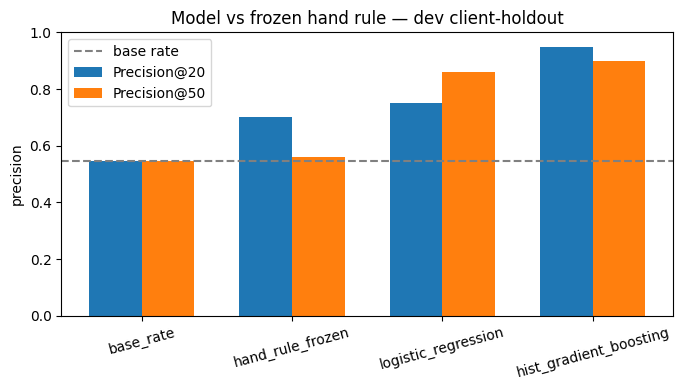

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(results_df)); w = 0.35
ax.bar(x - w/2, results_df["p@20"], w, label="Precision@20")
ax.bar(x + w/2, results_df["p@50"], w, label="Precision@50")
ax.axhline(float(y_te.mean()), ls="--", c="gray", label="base rate")
ax.set_xticks(x); ax.set_xticklabels(results_df["model"], rotation=15)
ax.set_ylabel("precision"); ax.set_ylim(0, 1); ax.legend()
ax.set_title("Model vs frozen hand rule — dev client-holdout")
plt.tight_layout(); plt.savefig("work/outputs/model_vs_baseline.png", dpi=150)
plt.show()

In [17]:
results_df.to_json("work/outputs/capstone_comparison.json", orient="records", indent=2)
print("artifacts written: model_vs_baseline.png, capstone_comparison.json, capstone_final_metrics.json")

artifacts written: model_vs_baseline.png, capstone_comparison.json, capstone_final_metrics.json


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
